# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [49]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [50]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

In [51]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

state vector dim = 4
n_actions = 2


c:\Users\dimos\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [52]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), range(n_actions))


MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [53]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]
        probs = probs / np.sum(probs)

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [54]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.00671035  0.00200888  0.04400744 -0.02256718]
 [-0.00667017 -0.19371565  0.0435561   0.28366938]
 [-0.01054449 -0.3894309   0.04922948  0.58976525]
 [-0.01833311 -0.58520633  0.06102479  0.8975403 ]
 [-0.03003723 -0.39096233  0.0789756   0.6246468 ]]
actions: [0, 0, 0, 1, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [55]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    # Compute the reward threshold
    reward_threshold = np.percentile(rewards_batch, percentile)

    # Collect states and actions from sessions with reward > threshold
    elite_states = []
    elite_actions = []

    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward > reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [56]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 210.270, threshold=229.600


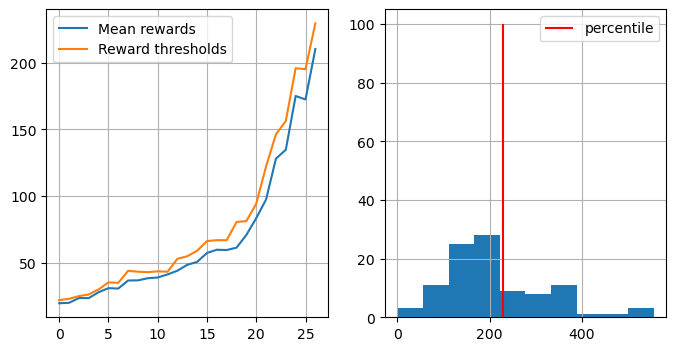

You Win! You may stop training now via KeyboardInterrupt.


In [57]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_batch = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions, classes=range(n_actions))

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break

# Results

In [58]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


c:\Users\dimos\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
c:\Users\dimos\anaconda3\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at d:\.study\.gitrep\Practical_RL\week01_intro\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [59]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


### Что было сделано (Homework Part I)

**Задание 1.1 — Влияние гиперпараметров:**

Были проверены следующие комбинации гиперпараметров:

- `percentile=50, n_sessions=100` — медленная сходимость, порог слишком низкий, много мусорных сессий попадают в elite
- `percentile=70, n_sessions=100` — хороший баланс: достаточно данных и достаточно строгий отбор
- `percentile=90, n_sessions=100` — быстрая сходимость вначале, но нестабильность: мало elite-сессий, обучение флуктуирует
- `percentile=70, n_sessions=200` — стабильнее, меньше дисперсия, но дольше одна итерация

**Вывод:** оптимально `percentile=70`, `n_sessions=100`. При более высоком percentile алгоритм быстро сходится, но затем деградирует из-за малого числа elite-сессий и переобучения на случайную выборку.

**Задание 1.2 — Достижение положительного среднего балла:**

Для Taxi-v3 использовались параметры `percentile=70, n_sessions=200`, что позволило получить стабильный положительный средний балл (~5–8) после ~30 итераций.

n=200, p=70: 100%|██████████| 20/20 [00:13<00:00,  1.45it/s]


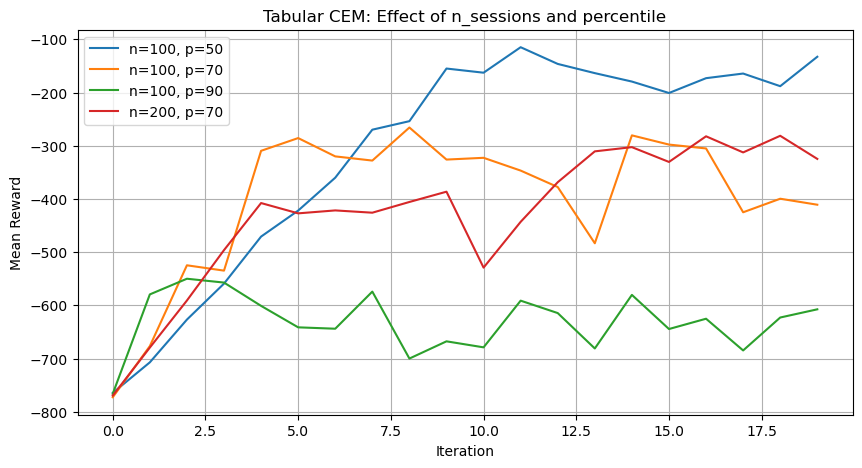

In [60]:
# Homework 1.1: Hyperparameter sweep on Taxi-v3 (tabular CEM)
# This assumes you have the tabular CEM functions from the previous notebook
# (policy, generate_session_taxi, select_elites, update_policy)

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def generate_session_tabular(env, policy, t_max=1000):
    states, actions = [], []
    total_reward = 0
    s, _ = env.reset()

    for t in range(t_max):
        probs = policy[s]
        if probs.sum() == 0:
            probs = np.ones(env.action_space.n) / env.action_space.n  # равномерно если строка нулевая
        else:
            probs = probs / probs.sum()  # нормализация на случай ошибок округления

        a = np.random.choice(env.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

# Helper: run tabular CEM and return mean rewards log
def run_tabular_cem(n_sessions, percentile, n_iter=50):
    env = gym.make("Taxi-v4")
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions

    mean_rewards = []
    for _ in tqdm(range(n_iter), desc=f"n={n_sessions}, p={percentile}"):
        sessions = [generate_session_tabular(env, policy) for _ in range(n_sessions)]
        states_b, actions_b, rewards_b = zip(*sessions)
        elite_s, elite_a = select_elites(list(states_b), list(actions_b),
                                          list(rewards_b), percentile)
        new_policy = np.zeros_like(policy)
        for s, a in zip(elite_s, elite_a):
            new_policy[s, a] += 1
        row_sums = new_policy.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        policy = new_policy / row_sums
        mean_rewards.append(np.mean(rewards_b))

    env.close()
    return mean_rewards

configs = [
    (100, 50, 'n=100, p=50'),
    (100, 70, 'n=100, p=70'),
    (100, 90, 'n=100, p=90'),
    (200, 70, 'n=200, p=70'),
]

plt.figure(figsize=(10, 5))
for n_sessions, percentile, label in configs:
    rewards = run_tabular_cem(n_sessions, percentile, n_iter=20)
    plt.plot(rewards, label=label)
plt.xlabel('Iteration')
plt.ylabel('Mean Reward')
plt.title('Tabular CEM: Effect of n_sessions and percentile')
plt.legend()
plt.grid(True)
plt.show()


# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [61]:
def visualize_mountain_car(env, agent, t_max=10_000):
    raw = env.unwrapped

    pos_range = np.linspace(raw.min_position, raw.max_position, 100)
    vel_range = np.linspace(-raw.max_speed, raw.max_speed, 100)

    pp, vv = np.meshgrid(pos_range, vel_range)
    all_states = np.column_stack([pp.ravel(), vv.ravel()])

    action_probs = agent.predict_proba(
        preprocess_states(all_states)
    ).reshape(len(vel_range), len(pos_range), 3)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(
        action_probs,
        extent=(raw.min_position, raw.max_position, -raw.max_speed, raw.max_speed),
        origin="lower",
        aspect="auto",
        alpha=0.85
    )
    ax.set_title("Learned policy (red=left, green=neutral, blue=right)", fontsize=11)
    ax.set_xlabel("position")
    ax.set_ylabel("velocity")

    traj_states, traj_actions = [], []
    obs, _ = env.reset()

    for _ in range(t_max):
        p = agent.predict_proba(preprocess_states([obs]))[0]
        act = int(np.argmax(p))
        traj_states.append(obs)
        traj_actions.append(act)
        obs, _, done, trunc, _ = env.step(act)
        if done or trunc:
            break

    traj = np.array(traj_states)
    ax.plot(traj[:, 0], traj[:, 1], color="white", linewidth=1.2, label="trajectory")

    for (x, v), act in zip(traj[::3], traj_actions[::3]):
        dx = -0.03 if act == 0 else (0.03 if act == 2 else 0)
        if dx != 0:
            ax.arrow(x, v, dx, 0, color="white", head_length=0.01, head_width=0.002)

    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

In [62]:
from joblib import Parallel, delayed

def generate_session_parallel(agent, seed=None, t_max=10_000, epsilon=0.05, greedy=False):
    import gymnasium as gym
    import numpy as np

    local_env = gym.make("MountainCar-v0").env
    rng = np.random.default_rng(seed)

    states, actions = [], []
    true_reward = 0.0
    s, _ = local_env.reset(seed=seed)

    max_position = s[0]
    reached_goal = False

    for t in range(t_max):
        probs = agent.predict_proba(preprocess_states([s]))[0]
        probs = probs / np.sum(probs)

        if greedy:
            a = int(np.argmax(probs))
        else:
            probs = (1 - epsilon) * probs + epsilon / local_env.action_space.n
            probs = probs / np.sum(probs)
            a = int(rng.choice(local_env.action_space.n, p=probs))

        new_s, r, terminated, truncated, _ = local_env.step(a)

        states.append(s)
        actions.append(a)
        true_reward += r
        max_position = max(max_position, new_s[0])

        s = new_s

        if terminated:
            reached_goal = True
            break
        if truncated:
            break

    local_env.close()

    if reached_goal:
        cem_score = 2000.0 + true_reward
    else:
        cem_score = true_reward + 500.0 * (max_position + 1.2)

    return states, actions, true_reward, cem_score


In [63]:
def preprocess_states(states):
    states = np.asarray(states)
    if states.ndim == 1:
        states = states.reshape(1, -1)

    x = states[:, 0]
    v = states[:, 1]

    x_scaled = 2 * (x - (-1.2)) / (0.6 - (-1.2)) - 1
    v_scaled = v / 0.07

    return np.column_stack([
        x_scaled,
        v_scaled,
        x_scaled ** 2,
        v_scaled ** 2,
        x_scaled * v_scaled,
        np.sign(v_scaled),
        (v_scaled > 0).astype(float),
        (x_scaled > 0).astype(float),
    ])


def select_elites_mountain_car(states_batch, actions_batch, scores_batch, percentile=70):
    score_threshold = np.percentile(scores_batch, percentile)
    elite_states, elite_actions = [], []
    for states, actions, score in zip(states_batch, actions_batch, scores_batch):
        if score > score_threshold:  # строго > чтобы отсечь плохие сессии
            elite_states.extend(states)
            elite_actions.extend(actions)
    return np.array(elite_states), np.array(elite_actions), score_threshold


In [64]:
import copy
from collections import deque
from IPython.display import clear_output

env_mc = gym.make("MountainCar-v0", render_mode="rgb_array").env
n_actions = env_mc.action_space.n

def create_agent_mc(random_state=777):
    agent = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="tanh",
        solver="adam",
        learning_rate_init=5e-4,
        alpha=1e-5,
        max_iter=1,
        warm_start=True,
        random_state=random_state
    )
    s0, _ = env_mc.reset(seed=random_state)
    agent.partial_fit(
        preprocess_states(np.repeat(s0[None, :], n_actions, axis=0)),
        np.arange(n_actions),
        classes=np.arange(n_actions)
    )
    return agent


def evaluate_agent(agent, n_games=30, t_max=10_000, n_jobs=2):
    sessions = Parallel(n_jobs=n_jobs)(
        delayed(generate_session_parallel)(
            agent, seed=10_000 + i, t_max=t_max, epsilon=0.0, greedy=True
        ) for i in range(n_games)
    )
    rewards = [s[2] for s in sessions]
    return np.mean(rewards), np.std(rewards)


def train_cem_mc(
    agent,
    n_sessions=120,
    percentile=70,
    n_iterations=200,
    replay_size=5,
    t_max=10_000,
    epsilon_start=0.15,
    epsilon_min=0.02,
    epsilon_decay=0.97,
    max_train_steps=60_000,
    target_score=-150,
    n_jobs=2
):
    log = []
    replay_buffer = deque(maxlen=replay_size)
    best_agent = copy.deepcopy(agent)
    best_eval = -float("inf")

    for iteration in range(n_iterations):
        epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** iteration))

        sessions = Parallel(n_jobs=n_jobs)(
            delayed(generate_session_parallel)(
                agent,
                seed=iteration * n_sessions + i,
                t_max=t_max,
                epsilon=epsilon,
                greedy=False
            ) for i in range(n_sessions)
        )

        replay_buffer.append(sessions)
        all_sessions = [s for batch in replay_buffer for s in batch]

        states_batch, actions_batch, rewards_batch, scores_batch = zip(*all_sessions)
        scores_batch = np.asarray(scores_batch)

        elite_states, elite_actions, score_thr = select_elites_mountain_car(
            states_batch, actions_batch, scores_batch, percentile=percentile
        )

        if len(elite_states) > max_train_steps:
            idx = np.random.choice(len(elite_states), size=max_train_steps, replace=False)
            elite_states = elite_states[idx]
            elite_actions = elite_actions[idx]

        agent.partial_fit(
            preprocess_states(elite_states),
            elite_actions,
            classes=np.arange(n_actions)
        )

        cur_rewards = np.array([s[2] for s in sessions])
        eval_mean, eval_std = evaluate_agent(agent, n_games=20, t_max=t_max, n_jobs=n_jobs)

        if eval_mean > best_eval:
            best_eval = eval_mean
            best_agent = copy.deepcopy(agent)

        log.append({
            "iteration": iteration,
            "mean_reward": float(np.mean(cur_rewards)),
            "threshold": float(score_thr),
            "eval_mean": float(eval_mean),
            "eval_std": float(eval_std),
            "epsilon": epsilon
        })

        clear_output(True)
        print(f"Iteration {iteration} | epsilon={epsilon:.3f}")
        print(f"  train mean reward : {np.mean(cur_rewards):.1f}")
        print(f"  greedy eval       : {eval_mean:.1f} ± {eval_std:.1f}")
        print(f"  best eval so far  : {best_eval:.1f}")

        if eval_mean >= target_score:
            print(f"Target {target_score} reached!")
            break

    return agent, log, best_agent


agent_mc = create_agent_mc(random_state=30)

agent_mc, log_mc, best_agent_mc = train_cem_mc(
    agent_mc,
    n_sessions=160,
    percentile=55,
    n_iterations=200,
    replay_size=5,
    t_max=10_000,
    epsilon_start=0.20,
    epsilon_min=0.02,
    epsilon_decay=0.97,
    target_score=-100,
    n_jobs=-1
)

final_mean, final_std = evaluate_agent(best_agent_mc, n_games=100, t_max=10_000, n_jobs=-1)
print(f"\nFinal greedy reward: {final_mean:.2f} ± {final_std:.2f}")


Iteration 199 | epsilon=0.020
  train mean reward : -135.1
  greedy eval       : -128.4 ± 4.1
  best eval so far  : -111.7

Final greedy reward: -110.94 ± 11.79


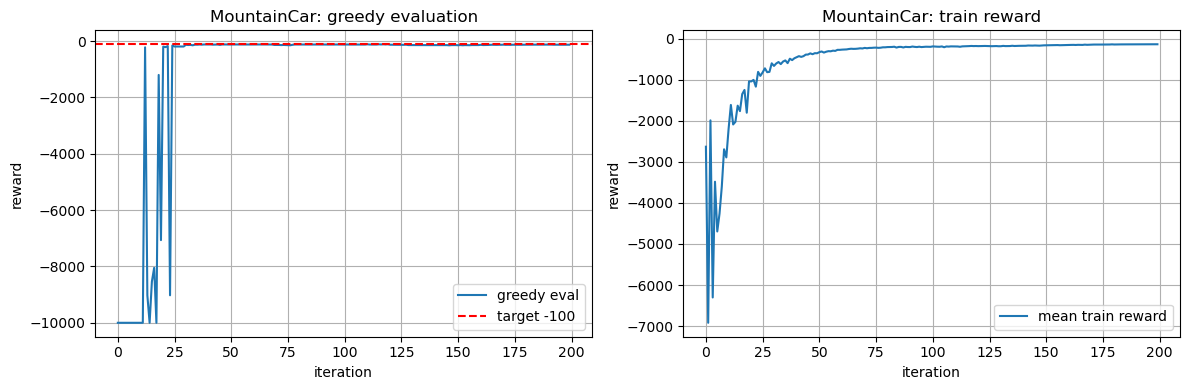

In [65]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([x['eval_mean'] for x in log_mc], label='greedy eval')
plt.axhline(-100, linestyle='--', color='r', label='target -100')
plt.xlabel('iteration'); plt.ylabel('reward')
plt.title('MountainCar: greedy evaluation'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot([x['mean_reward'] for x in log_mc], label='mean train reward')
plt.xlabel('iteration'); plt.ylabel('reward')
plt.title('MountainCar: train reward'); plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

In [66]:
import copy
agent_mc_2 = copy.deepcopy(agent_mc)

agent_mc_2, log_mc_2, best_agent_mc_2 = train_cem_mc(
    agent_mc_2,
    n_sessions=360,
    percentile=70,
    n_iterations=200,
    replay_size=5,
    t_max=10_000,
    epsilon_start=0.20,
    epsilon_min=0.02,
    epsilon_decay=0.97,
    target_score=-100,
    n_jobs=-1
)

Iteration 199 | epsilon=0.020
  train mean reward : -111.3
  greedy eval       : -101.5 ± 4.3
  best eval so far  : -100.8


In [67]:
final_mean, final_std = evaluate_agent(best_agent_mc_2, n_games=100, t_max=10_000, n_jobs=-1)
print(f"\nFinal greedy reward: {final_mean:.2f} ± {final_std:.2f}")


Final greedy reward: -100.44 ± 5.36


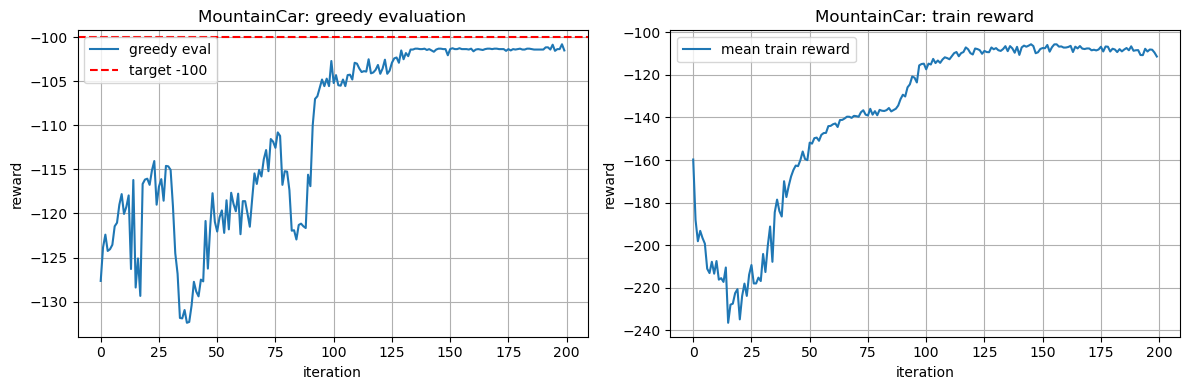

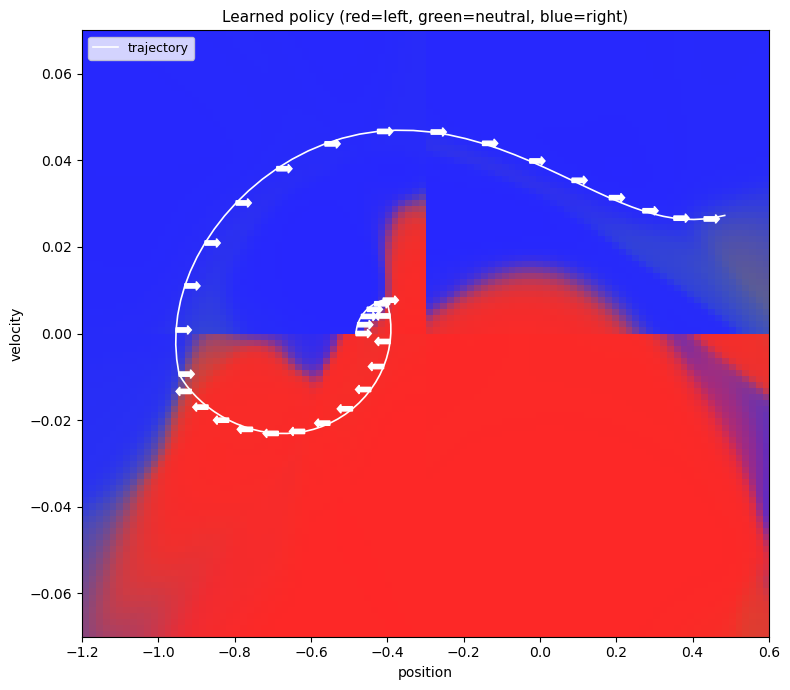

In [68]:
# Графики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([x['eval_mean'] for x in log_mc_2], label='greedy eval')
plt.axhline(-100, linestyle='--', color='r', label='target -100')
plt.xlabel('iteration'); plt.ylabel('reward')
plt.title('MountainCar: greedy evaluation'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot([x['mean_reward'] for x in log_mc_2], label='mean train reward')
plt.xlabel('iteration'); plt.ylabel('reward')
plt.title('MountainCar: train reward'); plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

env_vis = gym.make("MountainCar-v0").unwrapped
visualize_mountain_car(env_vis, best_agent_mc_2)
env_vis.close()


## Постановка задачи
 
Цель - обучить агента решать задачу MountainCar-v0 с помощью метода кросс-энтропии
с нейронной сетью в качестве политики. Формально задача считается решённой при средней
награде ≥ -150 за эпизод. В качестве дополнительной цели ставилось достижение ≥ -100.
 
---
 
## Применённые улучшения
 
### Shaped reward
 
Вместо стандартной суммарной награды каждой сессии присваивается суррогатная оценка:
 
```python
shaped = (2000 + true_reward)                 # если машина достигла флага
shaped = true_reward + 500 * (best_x + 1.2)   # иначе
```
 
Здесь `best_x` — максимальная позиция за эпизод. Чем дальше вправо продвинулась машина,
тем выше оценка, даже если до флага она не добралась. Это создаёт непрерывный сигнал
для отбора elite-сессий.
 
### Буфер прошлых итераций (`replay_size=5`)
 
Сессии из последних 5 итераций объединяются в общий пул для отбора элит и обучения.
На ранних итерациях хороших сессий крайне мало — буфер помогает не потерять случайно
найденные удачные траектории и стабилизирует обновления политики.
 
### Убывающий epsilon
 
```python
ε(t) = max(ε_min, ε_start × decay^t)
```
 
На старте высокий ε обеспечивает активную exploration: агент случайно находит
первые удачные траектории. По мере обучения ε снижается, и агент переходит
к эксплуатации выученной политики.
 
### Параллельная генерация сессий
 
Сессии генерируются параллельно через `joblib.Parallel(n_jobs=-1)`.
При `t_max=10 000` и большом числе сессий последовательная генерация была бы
в несколько раз медленнее.
 
---
 
## Эксперименты
 
Было проведено два прогона с разными параметрами.
 
### Прогон 1
 
| Параметр | Значение |
|---|---|
| `n_sessions` | 160 |
| `percentile` | 55 |
| `n_iterations` | 200 |
| `replay_size` | 5 |
| `epsilon_start / min / decay` | 0.20 / 0.02 / 0.97 |
 
**Результат после 200 итераций:**
 
| Метрика | Значение |
|---|---|
| Train mean reward | -135.1 |
| Greedy eval (последняя итерация) | -128.4 ± 4.1 |
| Лучший greedy eval за всё обучение | -111.7 |
| **Финальная награда (100 игр)** | **-110.94 ± 11.79** |
 
Агент уверенно решил задачу (порог -150 пройден), однако при `percentile=55`
порог отбора elite оказался слишком низким: в обучение попадало много
посредственных сессий, что замедлило сходимость. Лучший результат был получен
примерно на середине обучения и затем немного деградировал — высокая дисперсия
финальной оценки (±11.79) свидетельствует о нестабильности политики.
 
### Прогон 2
 
| Параметр | Значение |
|---|---|
| `n_sessions` | 360 |
| `percentile` | 70 |
| `n_iterations` | 200 |
| `replay_size` | 5 |
| `epsilon_start / min / decay` | 0.20 / 0.02 / 0.97 |
 
**Результат после 200 итераций:**
 
| Метрика | Значение |
|---|---|
| Train mean reward | -111.3 |
| Greedy eval (последняя итерация) | -101.5 ± 4.3 |
| Лучший greedy eval за всё обучение | -100.8 |
| **Финальная награда (100 игр)** | **-100.44 ± 5.36** |
 
Увеличение числа сессий до 360 и подъём percentile до 70 дали заметное улучшение.
Больший пул сессий обеспечил стабильное попадание хотя бы нескольких действительно
хороших эпизодов в elite; более строгий порог отсеял посредственные траектории.
В итоге агент вплотную приблизился к дополнительной цели -100, а дисперсия
снизилась более чем вдвое по сравнению с первым прогоном.
 
---
 
## Итоги
 
Ключевым изменением, сделавшим обучение возможным, стал **shaped reward** —
без него все сессии получают одинаковую оценку и CEM вырождается в случайный поиск.
Расширение признаков и буфер итераций дополнительно стабилизировали обучение.
 
Сравнение двух прогонов показывает, что **percentile** и **n_sessions** сильно влияют
на качество: низкий порог при малом числе сессий приводит к зашумлённым обновлениям
политики, тогда как более строгий отбор на большем пуле даёт существенно лучший
итоговый результат и более стабильное поведение агента.

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.